In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
df = pd.read_csv("../artifacts/data_ingestion/hotel_bookings.csv")

In [3]:
df.shape

(119390, 32)

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [6]:
df.sample(5, random_state=42)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30946,Resort Hotel,0,203,2016,December,49,2,2,5,2,...,No Deposit,250.0,NaN,0,Transient,66.8,0,0,Check-Out,2016-12-09
40207,City Hotel,1,82,2015,July,29,16,0,3,2,...,No Deposit,9.0,NaN,0,Transient,76.5,0,0,Canceled,2015-07-16
103708,City Hotel,0,25,2016,December,53,27,0,3,3,...,No Deposit,220.0,NaN,0,Transient-Party,60.0,0,1,Check-Out,2016-12-30
85144,City Hotel,0,1,2016,March,11,9,0,1,1,...,No Deposit,9.0,NaN,0,Transient-Party,95.0,0,0,Check-Out,2016-03-10
109991,City Hotel,0,70,2017,April,16,16,2,2,2,...,No Deposit,9.0,NaN,0,Transient,108.0,0,0,Check-Out,2017-04-20


In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.describe() # df.describe() automatically ignores missing (NaN) values while calculating statistics

# It calculates descriptive statistics only for numerical columns by default.

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
df.describe(include="object") # including objects and checking stats

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [11]:
df.isnull().sum() # checking missing values

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [12]:
df.duplicated().sum()

np.int64(31994)

In [13]:
df["hotel"].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [14]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [15]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [16]:
missing_values = df.isnull().sum()     # display columns missing values

missing_values[missing_values > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [17]:
missing_percentage = (df.isnull().sum() / len(df)) * 100   # calculating missing value percentage

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

In [18]:
df.duplicated().sum()     # duplicate values  only second occurance

np.int64(31994)

In [19]:
df[df.duplicated()]  # display duplicate rows

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [20]:
df[df.duplicated(keep=False)]  # Display Duplicate Rows (Including First Occurrence)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119372,City Hotel,0,175,2017,August,35,31,1,3,1,...,No Deposit,42.0,NaN,0,Transient,82.35,0,1,Check-Out,2017-09-04


In [21]:
duplicate_percentage = (df.duplicated().sum() / len(df)) * 100  # percentage of duplicate rows

print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Duplicate Percentage: 26.80%


In [22]:
df["is_canceled"].value_counts()  #count target class  # lot of bias not cancelled are more 0

is_canceled
0    75166
1    44224
Name: count, dtype: int64

# count values categorical plots

In [23]:
(df["is_canceled"].value_counts(normalize=True) * 100) # percentage # To calculate the percentage distribution of each class.

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

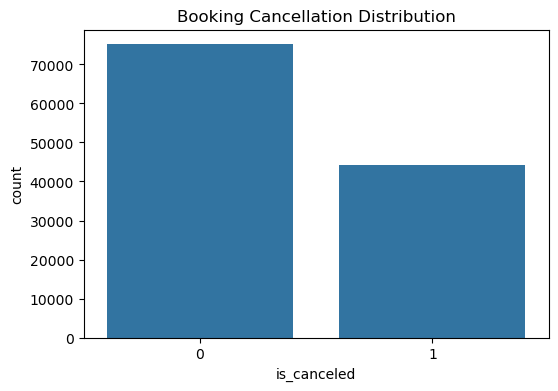

In [24]:
import seaborn as sns                     # data visuvalization of target 
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="is_canceled", data=df)

plt.title("Booking Cancellation Distribution")

plt.show()

In [25]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

categorical_features = df.select_dtypes(include=["object"]).columns

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)  # always separate the features num and categorical 

Numerical Features: Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')
Categorical Features: Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')


# Histogram 
A Histogram is used to visualize the distribution of a numerical feature by dividing the data into intervals (bins) and counting how many observations fall into each interval.

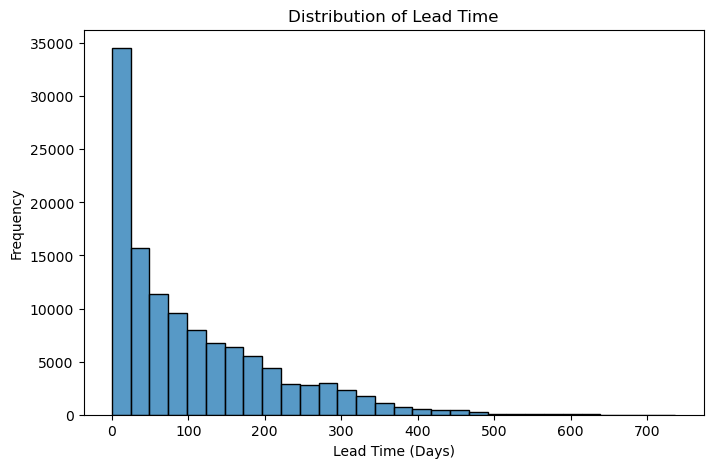

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["lead_time"], bins=30, kde=False)    # Right (Positive) Skewness. Most values are small, with a long tail to the right

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.show()

The distribution resembles an exponential-like decay; however, based solely on the histogram, it is more appropriate to describe it as a positively skewed distribution rather than conclusively stating it follows an exponential distribution.

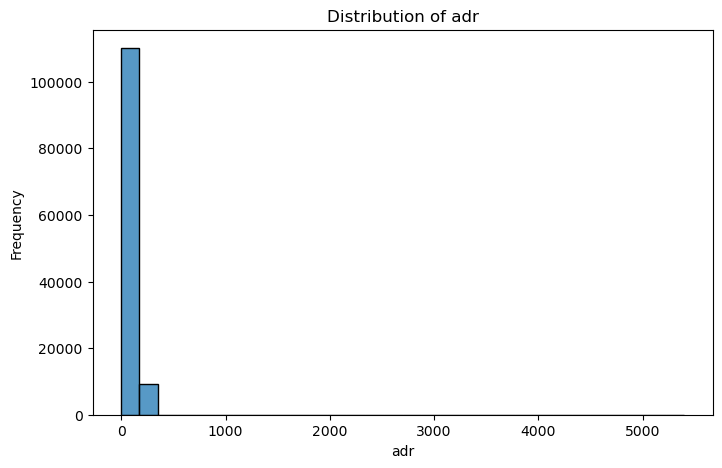

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["adr"], bins=30, kde=False)    # Right (Positive) Skewness. Most values are small, with a long tail to the right

plt.title("Distribution of adr")
plt.xlabel("adr")
plt.ylabel("Frequency")

plt.show()

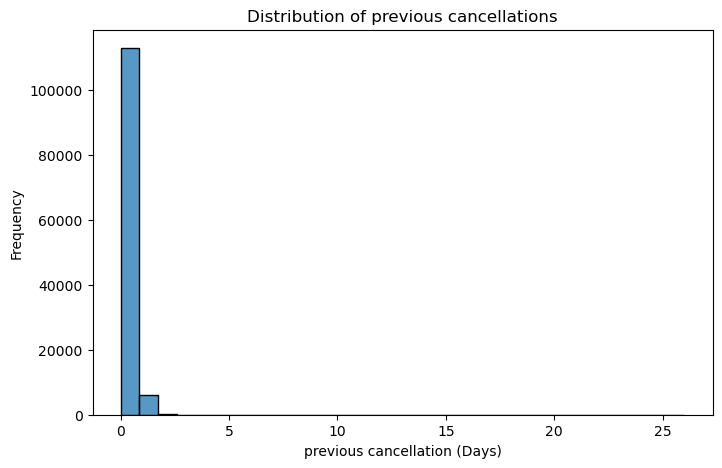

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["previous_cancellations"], bins=30, kde=False)    # Right (Positive) Skewness. Most values are small, with a long tail to the right

plt.title("Distribution of previous cancellations")
plt.xlabel("previous cancellation (Days)")
plt.ylabel("Frequency")

plt.show()

# box plot 

A Box Plot is a graphical representation of the distribution of a numerical feature using the Five Number Summary

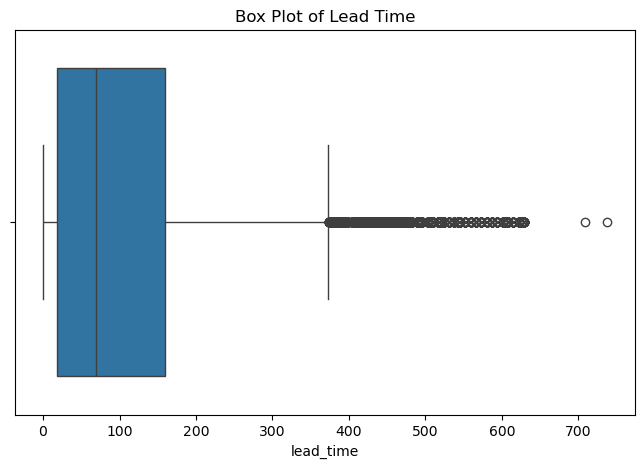

In [29]:
plt.figure(figsize=(8,5))     # box plot 

sns.boxplot(x=df["lead_time"])

plt.title("Box Plot of Lead Time")

plt.show()

The box plot of lead_time indicates a positively skewed distribution with numerous potential outliers on the higher end of the scale. The median lies closer to the lower quartile, while the upper whisker is considerably longer, reinforcing the presence of right skewness. These extreme lead time values likely represent customers who booked well in advance. Since such bookings are realistic in the hospitality domain, these observations should be investigated further rather than removed automatically.

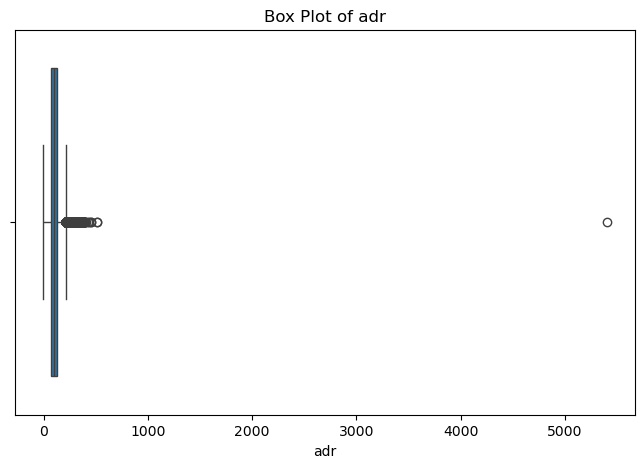

In [30]:
plt.figure(figsize=(8,5))     # box plot 

sns.boxplot(x=df["adr"])

plt.title("Box Plot of adr")

plt.show()

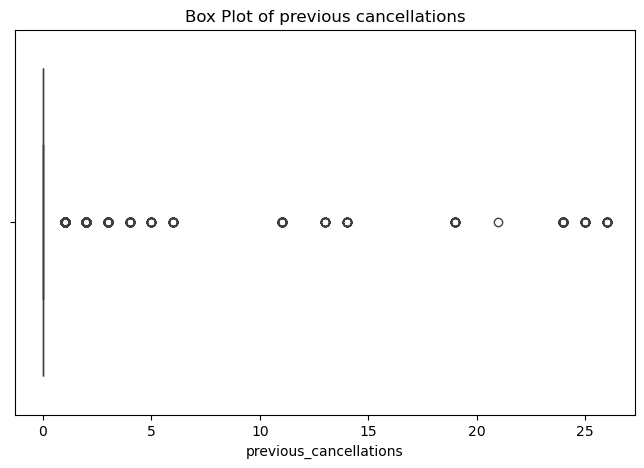

In [31]:
plt.figure(figsize=(8,5))     # box plot 

sns.boxplot(x=df["previous_cancellations"])

plt.title("Box Plot of previous cancellations")

plt.show()

# kde plot (kernel density estimation)

Kernel Density Estimation (KDE) is a statistical technique used to estimate the probability density of a continuous variable.

-One peak
-Long right tail
-Positive skew

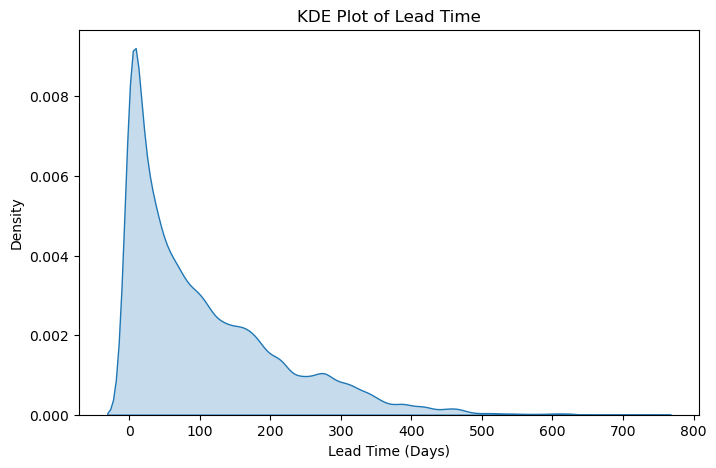

In [32]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["lead_time"], fill=True)

plt.title("KDE Plot of Lead Time")

plt.xlabel("Lead Time (Days)")

plt.show()

# Bi variate 

relationship between two variables feature and feature .
best identifying in boxplot  numeric and categorical

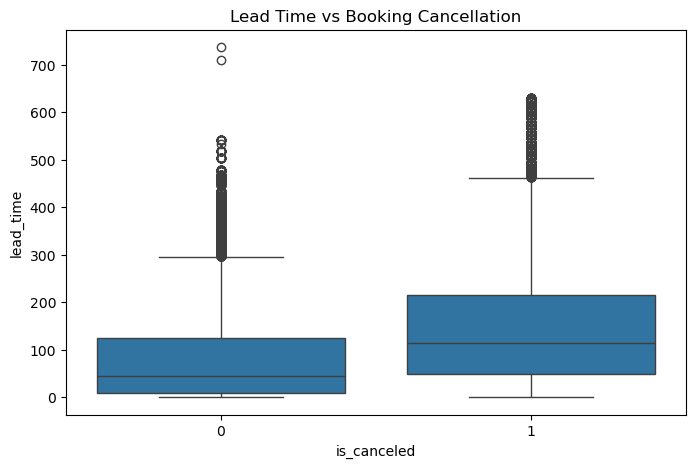

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_canceled",
    y="lead_time",
    data=df
)

plt.title("Lead Time vs Booking Cancellation")

plt.show()

# categorical vs target variable

categorical vs categorical variables

# crosstab

pd.crosstab() creates a contingency table showing the frequency of combinations between two categorical variables.

In [34]:
pd.crosstab(df["hotel"], df["is_canceled"])

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


In [35]:
pd.crosstab(                    # Percentage Crosstab
    df["hotel"],
    df["is_canceled"],
    normalize="index"
) * 100                 

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


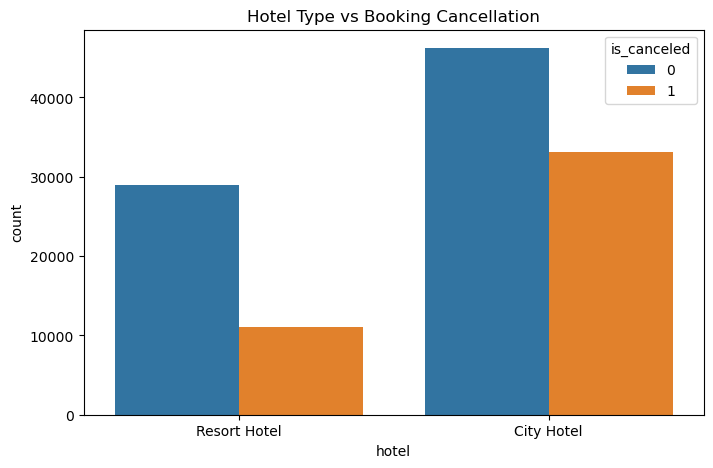

In [36]:
plt.figure(figsize=(8,5))           # Count Plot with Hue

sns.countplot(
    x="hotel",
    hue="is_canceled",
    data=df
)

plt.title("Hotel Type vs Booking Cancellation")

plt.show()

The analysis indicates that City Hotels account for a larger number of bookings than Resort Hotels.
City Hotels appear to have a higher proportion of cancelled bookings. This suggests that hotel type may be an important predictive feature for booking cancellation and should be retained during model development.

In [37]:
df["market_segment"].unique() # unique value

array(['Direct', 'Corporate', 'Online TA', 'Offline TA/TO',
       'Complementary', 'Groups', 'Undefined', 'Aviation'], dtype=object)

In [38]:
df["market_segment"].value_counts()    # Frequency

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [39]:
(                                       # percentage 
    df["market_segment"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

market_segment
Online TA        47.30
Offline TA/TO    20.29
Groups           16.59
Direct           10.56
Corporate         4.44
Complementary     0.62
Aviation          0.20
Undefined         0.00
Name: proportion, dtype: float64

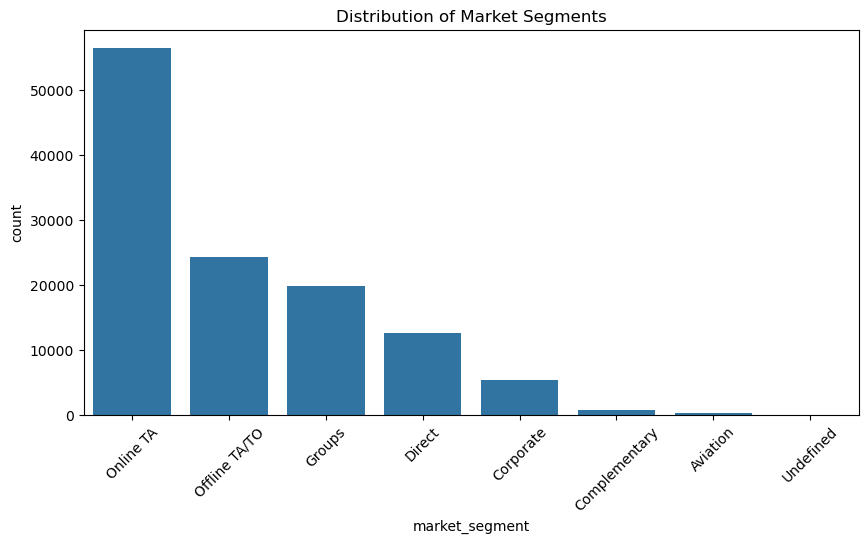

In [40]:
plt.figure(figsize=(10,5))                  # count plot for both categorical variables 

sns.countplot(
    data=df,
    x="market_segment",
    order=df["market_segment"].value_counts().index
)

plt.xticks(rotation=45) #  rotate because Offline TA/TO are long.Without rotation, labels overlap.

plt.title("Distribution of Market Segments")

plt.show()

In [41]:
pd.crosstab(                        # crosstab
    df["market_segment"],
    df["is_canceled"]
)

is_canceled,0,1
market_segment,,
Aviation,185,52
Complementary,646,97
Corporate,4303,992
Direct,10672,1934
Groups,7714,12097
Offline TA/TO,15908,8311
Online TA,35738,20739
Undefined,0,2


In [42]:
pd.crosstab(
    df["market_segment"],
    df["is_canceled"],
    normalize="index"
).mul(100).round(2)

is_canceled,0,1
market_segment,,
Aviation,78.06,21.94
Complementary,86.94,13.06
Corporate,81.27,18.73
Direct,84.66,15.34
Groups,38.94,61.06
Offline TA/TO,65.68,34.32
Online TA,63.28,36.72
Undefined,0.00,100.00


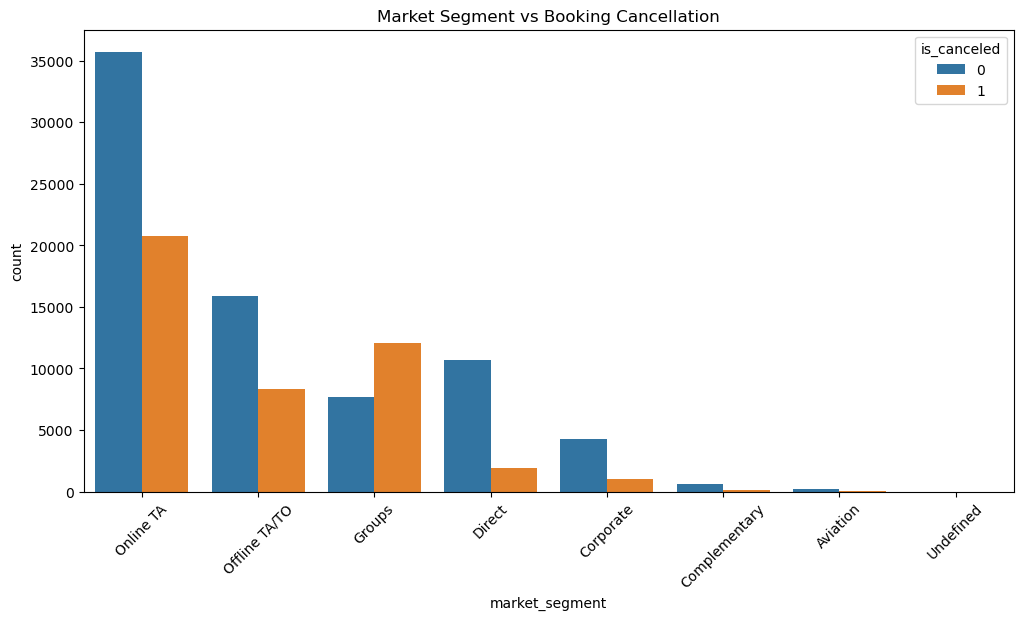

In [43]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="market_segment",
    hue="is_canceled",
    order=df["market_segment"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Market Segment vs Booking Cancellation")

plt.show()

In [44]:
# deposit_type vs is_canceled

df["deposit_type"].unique()

array(['No Deposit', 'Refundable', 'Non Refund'], dtype=object)

In [45]:
df["deposit_type"].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [46]:
(
    df["deposit_type"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

deposit_type
No Deposit    87.65
Non Refund    12.22
Refundable     0.14
Name: proportion, dtype: float64

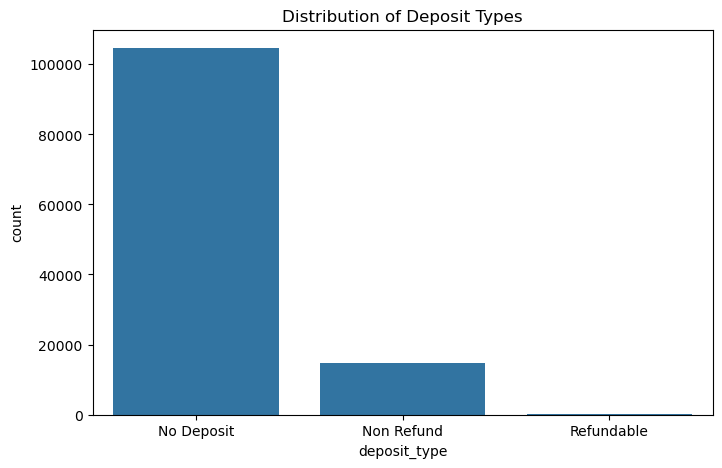

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="deposit_type",
    order=df["deposit_type"].value_counts().index
)

plt.title("Distribution of Deposit Types")

plt.show()

In [48]:
pd.crosstab(
    df["deposit_type"],
    df["is_canceled"]
)

is_canceled,0,1
deposit_type,,
No Deposit,74947,29694
Non Refund,93,14494
Refundable,126,36


In [49]:
pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
).mul(100).round(2)

is_canceled,0,1
deposit_type,,
No Deposit,71.62,28.38
Non Refund,0.64,99.36
Refundable,77.78,22.22


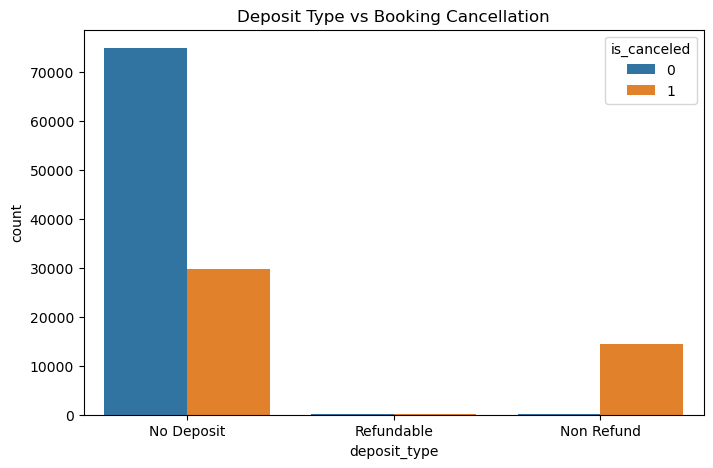

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="deposit_type",
    hue="is_canceled"
)

plt.title("Deposit Type vs Booking Cancellation")

plt.show()

In [51]:
# customer_type vs is_canceled

df["customer_type"].unique()

array(['Transient', 'Contract', 'Transient-Party', 'Group'], dtype=object)

In [52]:
df["customer_type"].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [53]:
(
    df["customer_type"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

customer_type
Transient          75.06
Transient-Party    21.04
Contract            3.41
Group               0.48
Name: proportion, dtype: float64

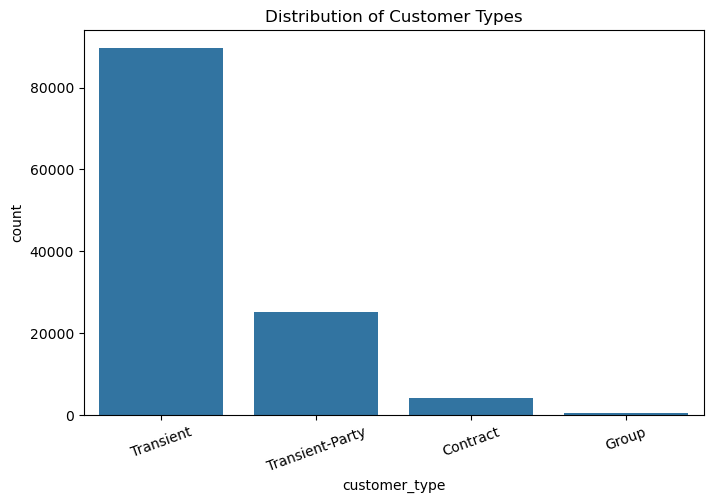

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="customer_type",
    order=df["customer_type"].value_counts().index
)

plt.title("Distribution of Customer Types")

plt.xticks(rotation=20)

plt.show()

In [55]:
pd.crosstab(
    df["customer_type"],
    df["is_canceled"]
)

is_canceled,0,1
customer_type,,
Contract,2814,1262
Group,518,59
Transient,53099,36514
Transient-Party,18735,6389


In [56]:
pd.crosstab(
    df["customer_type"],
    df["is_canceled"],
    normalize="index"
).mul(100).round(2)

is_canceled,0,1
customer_type,,
Contract,69.04,30.96
Group,89.77,10.23
Transient,59.25,40.75
Transient-Party,74.57,25.43


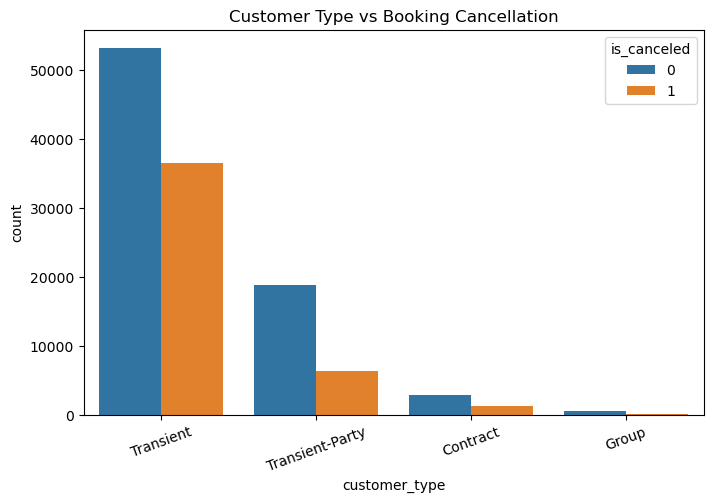

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="customer_type",
    hue="is_canceled",
    order=df["customer_type"].value_counts().index
)

plt.title("Customer Type vs Booking Cancellation")

plt.xticks(rotation=20)

plt.show()

# Correlation Analysis

Correlation measures the strength and direction of a relationship between two numerical variables.

In [58]:
numerical_features = df.select_dtypes(      # identify num variables
    include=["int64", "float64"]
).columns

numerical_features

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [59]:
correlation_matrix = df[numerical_features].corr()   # corelation matrix

correlation_matrix

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.293123,0.016660,0.008148,-0.006130,-0.001791,0.024765,0.060017,0.005048,-0.032491,-0.084793,0.110133,-0.057358,-0.144381,-0.083114,-0.020642,0.054186,0.047557,-0.195498,-0.234658
lead_time,0.293123,1.000000,0.040142,0.126871,0.002268,0.085671,0.165799,0.119519,-0.037622,-0.020915,-0.124410,0.086042,-0.073548,0.000149,-0.069741,0.151464,0.170084,-0.063077,-0.116451,-0.095712
arrival_date_year,0.016660,0.040142,1.000000,-0.540561,-0.000221,0.021497,0.030883,0.029635,0.054624,-0.013192,0.010341,-0.119822,0.029218,0.030872,0.063457,0.259095,-0.056497,0.197580,-0.013684,0.108531
arrival_date_week_number,0.008148,0.126871,-0.540561,1.000000,0.066809,0.018208,0.015558,0.025909,0.005518,0.010395,-0.030131,0.035501,-0.020904,0.005508,-0.031201,-0.076760,0.022933,0.075791,0.001920,0.026149
arrival_date_day_of_month,-0.006130,0.002268,-0.000221,0.066809,1.000000,-0.016354,-0.028174,-0.001566,0.014544,-0.000230,-0.006145,-0.027011,-0.000300,0.010613,0.001487,0.044858,0.022728,0.030245,0.008683,0.003062
stays_in_weekend_nights,-0.001791,0.085671,0.021497,0.018208,-0.016354,1.000000,0.498969,0.091871,0.045793,0.018483,-0.087239,-0.012775,-0.042715,0.063281,0.140739,0.066749,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.024765,0.165799,0.030883,0.015558,-0.028174,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,0.182382,0.182211,-0.002020,0.065237,-0.024859,0.068192
adults,0.060017,0.119519,0.029635,0.025909,-0.001566,0.091871,0.092976,1.000000,0.030447,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.035594,0.207793,-0.008283,0.230641,0.014785,0.122884
children,0.005048,-0.037622,0.054624,0.005518,0.014544,0.045793,0.044203,0.030447,1.000000,0.024030,-0.032859,-0.024730,-0.021072,0.048949,0.041066,0.030931,-0.033273,0.324854,0.056253,0.081745
babies,-0.032491,-0.020915,-0.013192,0.010395,-0.000230,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,0.036184,0.019206,-0.010621,0.029186,0.037383,0.097889


# heatmap

A correlation matrix can become difficult to read when you have many features.

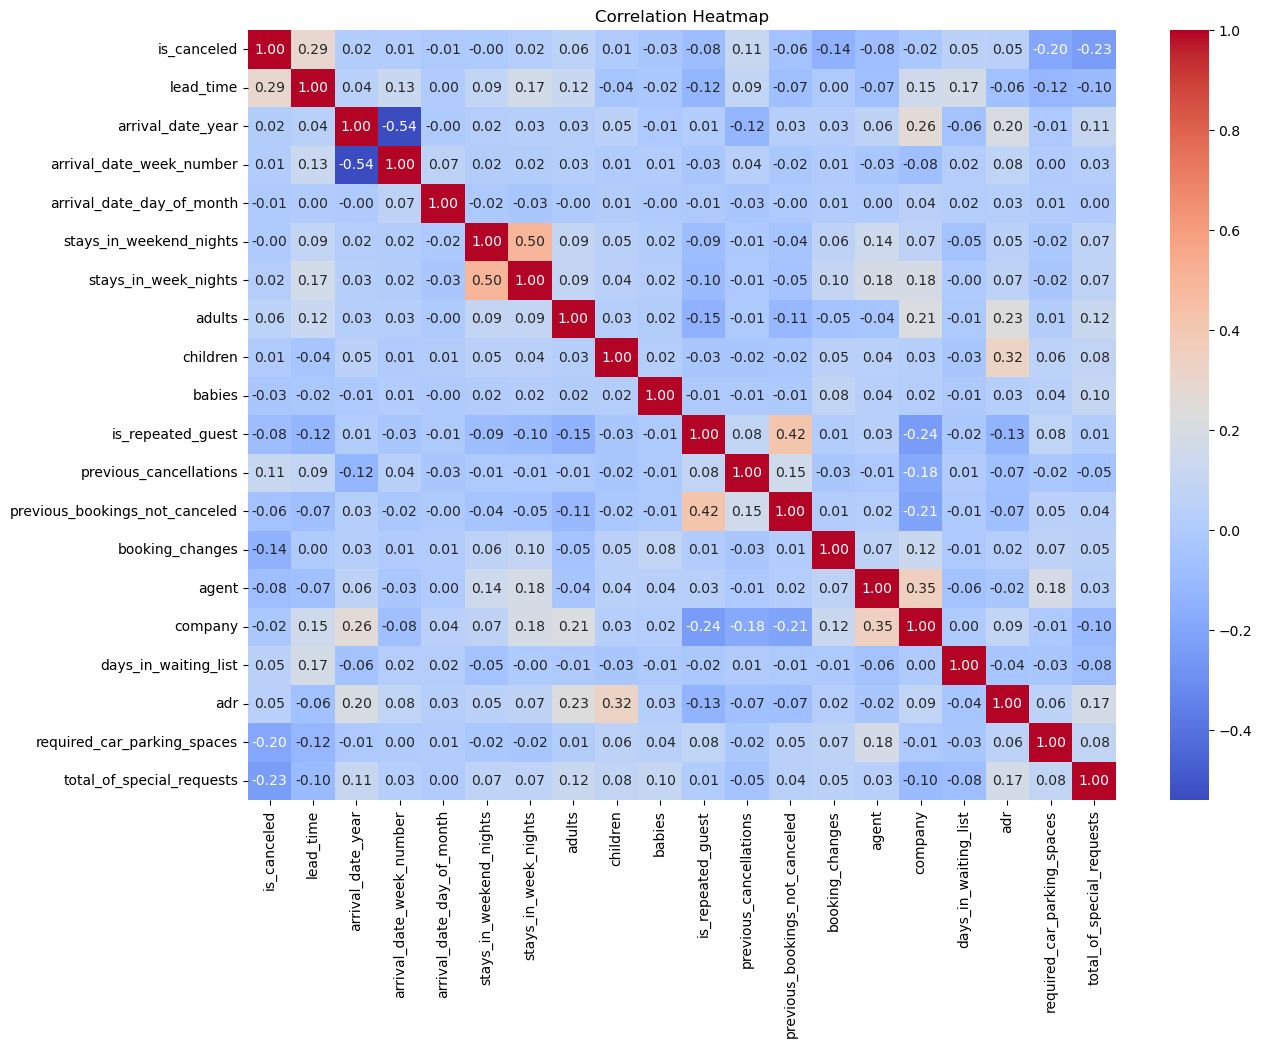

In [60]:
plt.figure(figsize=(14,10))              # heatmap

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [61]:
target_correlation = df[numerical_features].corrwith(   # correlation with target variables
    df["is_canceled"]
).sort_values(ascending=False)

target_correlation

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005048
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
company                          -0.020642
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
agent                            -0.083114
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
dtype: float64

Binning means converting a continuous numerical variable into a set of meaningful intervals or groups.

In [62]:
bins = [0, 30, 60, 120, 180, 365, float("inf")]

labels = [
    "0-30",
    "31-60",
    "61-120",
    "121-180",
    "181-365",
    "365+"
]

df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [63]:
df["lead_time_group"].value_counts().sort_index()   # check the groups

lead_time_group
0-30       38706
31-60      16970
61-120     23017
121-180    16005
181-365    21544
365+        3148
Name: count, dtype: int64

In [64]:
cancellation_rate = (                                           # cancellation rate
    df.groupby("lead_time_group", observed=True)["is_canceled"]
      .mean()
      .mul(100)
      .round(2)
)

cancellation_rate

lead_time_group
0-30       18.56
31-60      36.38
61-120     41.76
121-180    44.84
181-365    55.45
365+       67.66
Name: is_canceled, dtype: float64

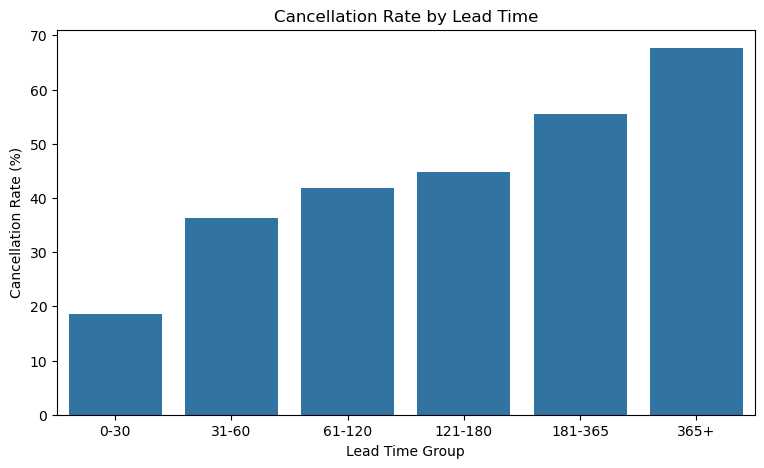

In [65]:
plt.figure(figsize=(9,5))          #visuvalization 

sns.barplot(
    x=cancellation_rate.index,
    y=cancellation_rate.values
)

plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")

plt.show()

In [66]:
numerical_features = [                             # checking outliers for all the numeric values
    "lead_time",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

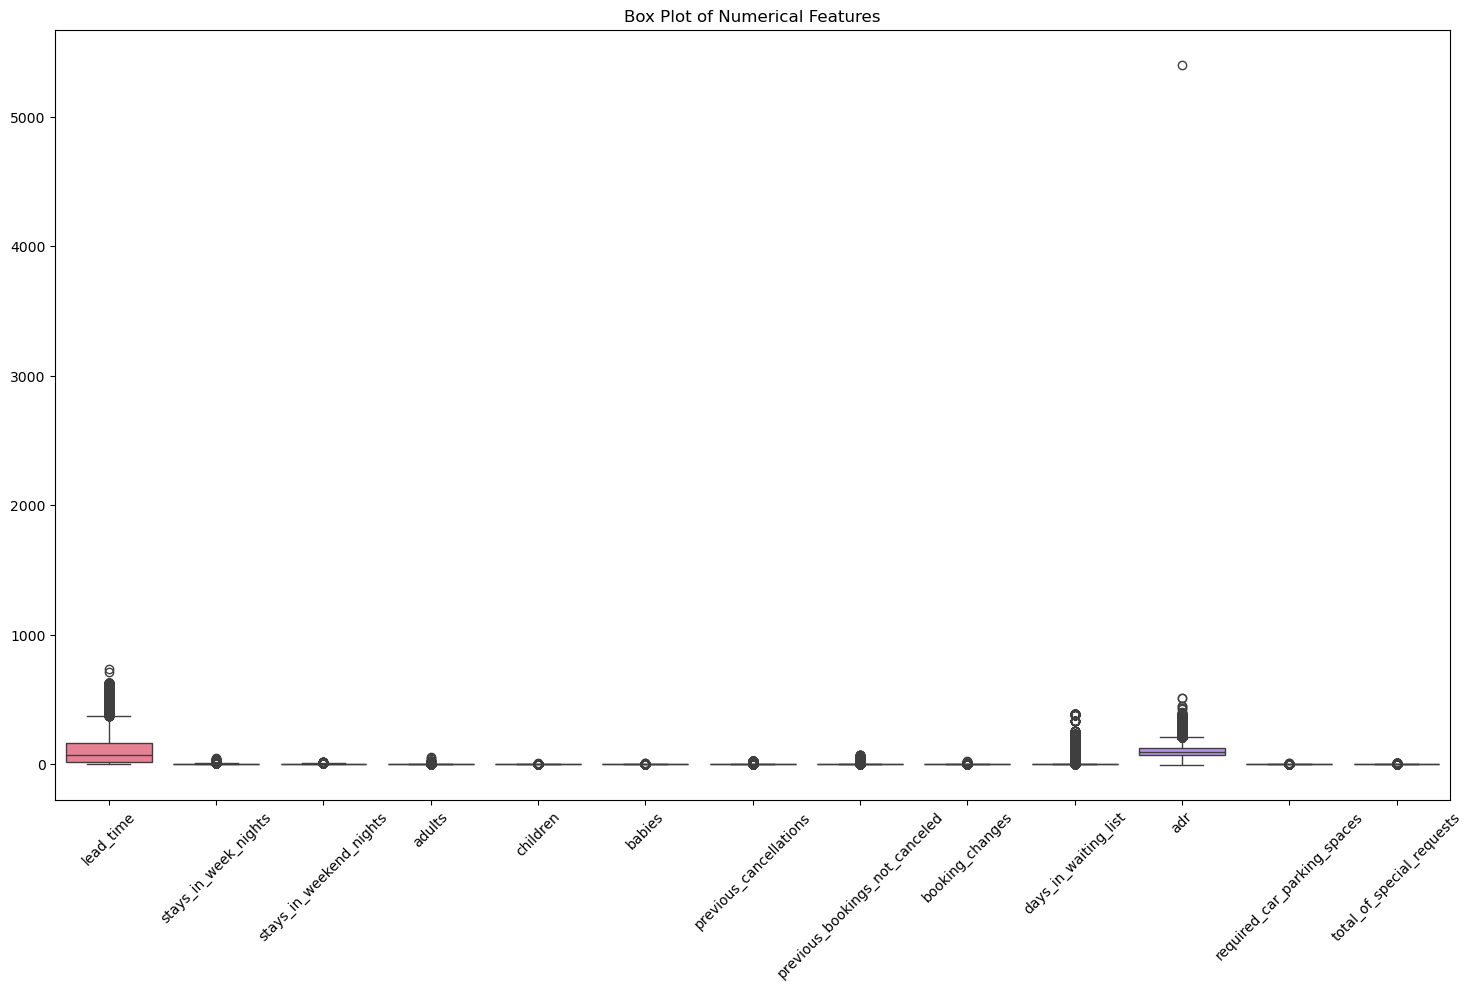

In [67]:
plt.figure(figsize=(18, 10))                  #boxplot plot

sns.boxplot(data=df[numerical_features])

plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Features")

plt.show()

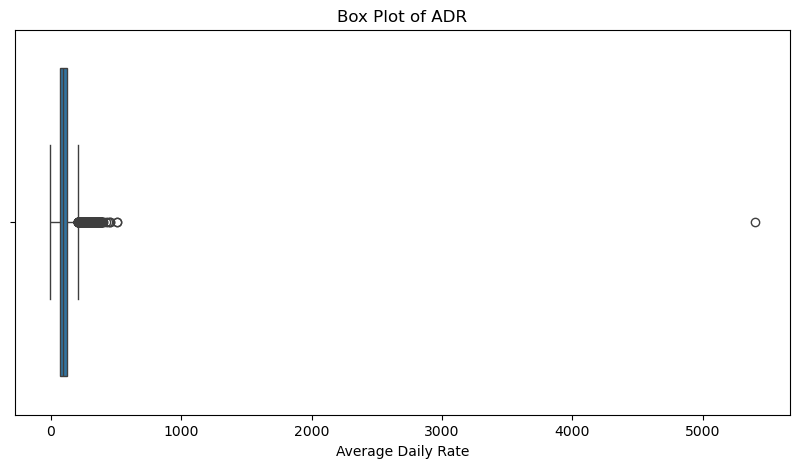

In [68]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["adr"])          # daily average rate in boxplot 

plt.title("Box Plot of ADR")
plt.xlabel("Average Daily Rate")

plt.show()

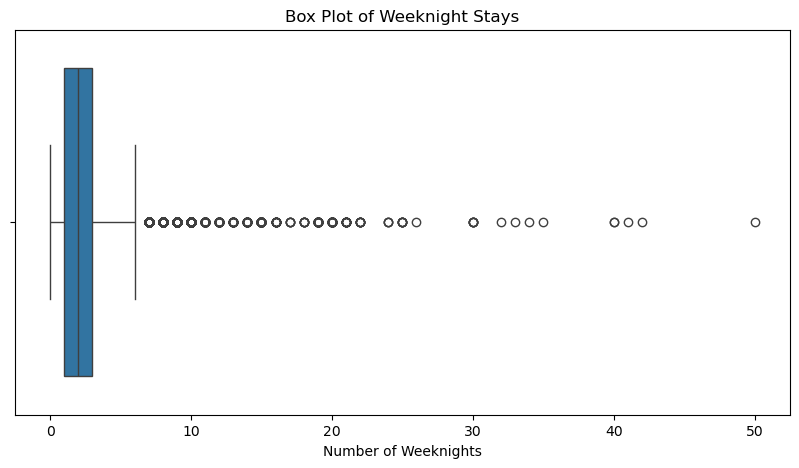

In [69]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["stays_in_week_nights"]) # stays in week nights in boxplot for outlier checking

plt.title("Box Plot of Weeknight Stays")

plt.xlabel("Number of Weeknights")

plt.show()

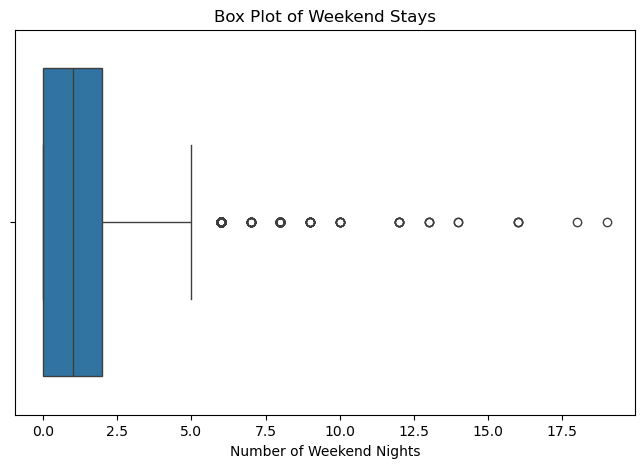

In [70]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["stays_in_weekend_nights"]) # stays in weekend nights in boxplot for outlier checking

plt.title("Box Plot of Weekend Stays")

plt.xlabel("Number of Weekend Nights")

plt.show()

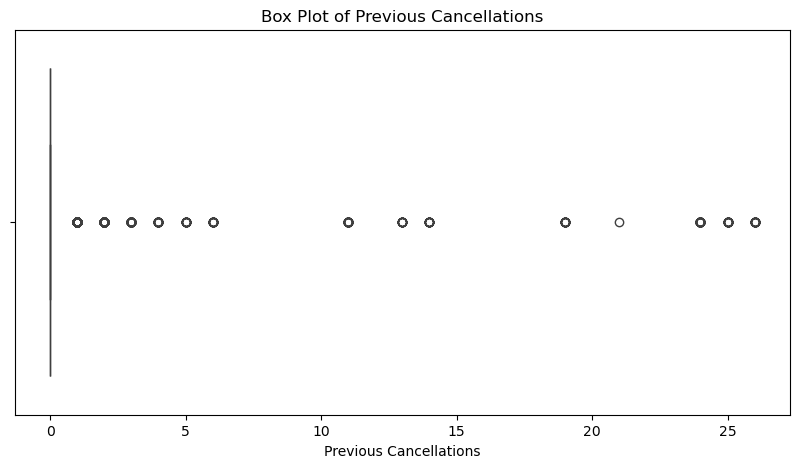

In [71]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["previous_cancellations"])

plt.title("Box Plot of Previous Cancellations")

plt.xlabel("Previous Cancellations")

plt.show()

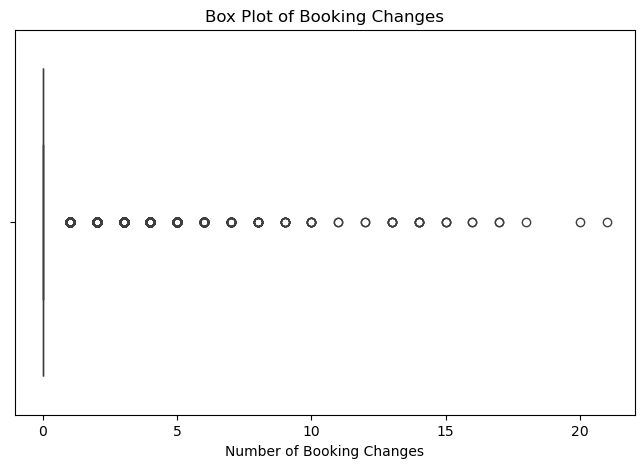

In [72]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["booking_changes"])

plt.title("Box Plot of Booking Changes")

plt.xlabel("Number of Booking Changes")

plt.show()

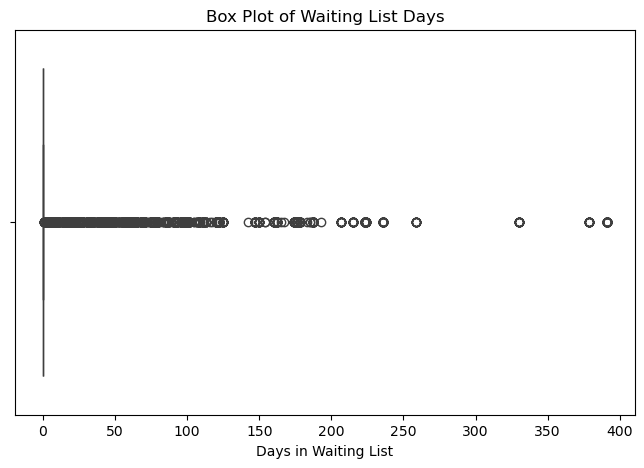

In [73]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["days_in_waiting_list"])

plt.title("Box Plot of Waiting List Days")

plt.xlabel("Days in Waiting List")

plt.show()

# Missing-Value Pattern Analysis

now we will find out deoes a value is missing have any relationship with cancellation.

In [74]:

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]  # missing value count

missing_values.sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

In [75]:
missing_percentage = (
    df.isnull().mean() * 100                   # missing percentage
).sort_values(ascending=False)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

missing_percentage.round(2)

company     94.31
agent       13.69
country      0.41
children     0.00
dtype: float64

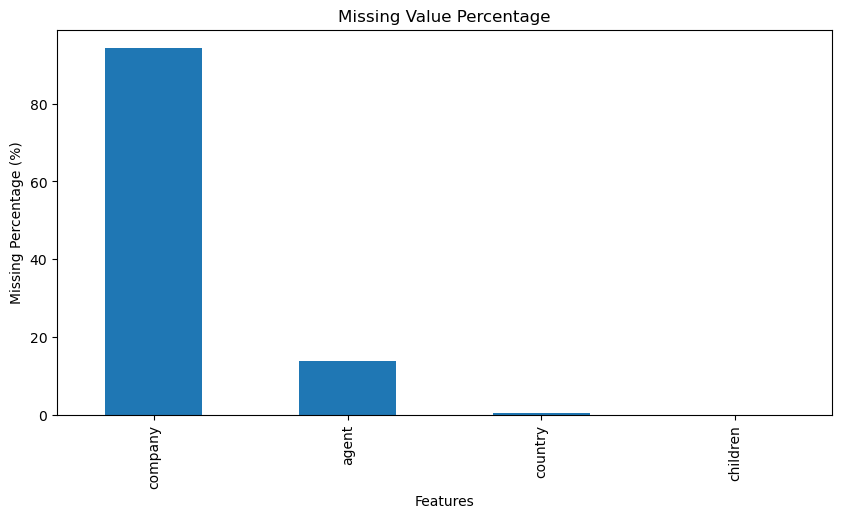

In [76]:
missing_percentage.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Missing Value Percentage")          # plot missing values
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")

plt.show()

In [77]:
df["country_missing"] = df["country"].isnull()

In [78]:
# Compare Cancellation Rates

df.groupby("country_missing")["is_canceled"].mean() * 100 

#false->country is present  true-> country not found

country_missing
False    37.137306
True     13.729508
Name: is_canceled, dtype: float64

In [79]:
df.groupby("country_missing")["is_canceled"].mean()    # using groupby we can combine both columns 


# .mean() calculates the proportion of cancelled bookings in each group

country_missing
False    0.371373
True     0.137295
Name: is_canceled, dtype: float64

In [80]:
# agent 

df["agent_missing"] = df["agent"].isnull()

df.groupby("agent_missing")["is_canceled"].mean() * 100

agent_missing
False    39.004367
True     24.663403
Name: is_canceled, dtype: float64

In [81]:
# company 

df["company_missing"] = df["company"].isnull()

df.groupby("company_missing")["is_canceled"].mean() * 100 
# Does missingness itself relate to the target we find this here by using groupby and mean 

company_missing
False    17.522436
True     38.219960
Name: is_canceled, dtype: float64

In [82]:
# childrens # only few values checking it directly

df["children"].isnull().sum()

np.int64(4)

In [83]:
df.drop(
    columns=[
        "country_missing", # previously i created temp so need to drop 
        "agent_missing",
        "company_missing"
    ],
)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time_group
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,181-365
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,365+
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,0-30
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,0-30
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,0-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06,0-30
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07,61-120
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07,31-60
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07,61-120


In [84]:
df.columns


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'lead_time_group',
       'country_missing', 'agent_missing', 'company_missing'],
      dtype='object')

In [85]:
df.drop(
    columns=["lead_time_group"],     # previously i created temp as lead_time_group so need to drop 
    inplace=True
)

In [86]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'country_missing',
       'agent_missing', 'company_missing'],
      dtype='object')

# Feature Relationship & Redundancy

We've already created the correlation heatmap, but now we need to use it properly 

In [87]:
correlation_matrix = df[numerical_features].corr()  #Correlation Matrix

In [88]:
corr_pairs = (
    correlation_matrix
    .where(
        ~np.eye(correlation_matrix.shape[0], dtype=bool)
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(20)


# It removes the diagonal i.e, equal to 1 because that's not useful.Then it shows the strongest relationships between different features

stays_in_weekend_nights         stays_in_week_nights              0.498969
stays_in_week_nights            stays_in_weekend_nights           0.498969
adr                             children                          0.324854
children                        adr                               0.324854
adults                          adr                               0.230641
adr                             adults                            0.230641
                                total_of_special_requests         0.172185
total_of_special_requests       adr                               0.172185
lead_time                       days_in_waiting_list              0.170084
days_in_waiting_list            lead_time                         0.170084
stays_in_week_nights            lead_time                         0.165799
lead_time                       stays_in_week_nights              0.165799
previous_cancellations          previous_bookings_not_canceled    0.152728
previous_bookings_not_can

In [89]:
# negative correlation 

strong_corr = (
    correlation_matrix
    .where(
        ~np.eye(correlation_matrix.shape[0], dtype=bool)
    )
    .stack()
)

strong_corr = strong_corr[
    strong_corr.abs() >= 0.70
].sort_values(key=abs, ascending=False)

strong_corr.head(20)

Series([], dtype: float64)

In [90]:
all_corr = (
    correlation_matrix
    .where(
        ~np.eye(correlation_matrix.shape[0], dtype=bool)
    )
    .stack()
)

all_corr.loc[
    all_corr.abs().sort_values(ascending=False).head(20).index
]

stays_in_weekend_nights         stays_in_week_nights              0.498969
stays_in_week_nights            stays_in_weekend_nights           0.498969
adr                             children                          0.324854
children                        adr                               0.324854
adults                          adr                               0.230641
adr                             adults                            0.230641
                                total_of_special_requests         0.172185
total_of_special_requests       adr                               0.172185
lead_time                       days_in_waiting_list              0.170084
days_in_waiting_list            lead_time                         0.170084
stays_in_week_nights            lead_time                         0.165799
lead_time                       stays_in_week_nights              0.165799
previous_cancellations          previous_bookings_not_canceled    0.152728
previous_bookings_not_can

In [91]:
# duplicate colums

duplicate_columns = df.columns[df.T.duplicated()]

duplicate_columns

Index([], dtype='object')

In [92]:
strong_corr = (
    correlation_matrix
    .where(
        ~np.eye(correlation_matrix.shape[0], dtype=bool)  # strong correlation values
    )
    .stack()
)

strong_corr = strong_corr[
    strong_corr.abs() >= 0.70
].sort_values(key=abs, ascending=False)

strong_corr.head(20)

Series([], dtype: float64)

In [93]:
duplicate_columns = df.columns[df.T.duplicated()]

duplicate_columns

Index([], dtype='object')